In [1]:
from functions.clustering_functions import clustering_2_communities, ARI_fscore
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
from functions.plots import plot_ARI_f1
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic, ask_yes_no, ask_input
from functions.cosmograph_functions import visualize_graph_paysim

In [2]:
user_input = ask_yes_no("\nDo you want to load data?")

name = 'PAYSIM'
if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)
    
else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)
    
results_squic = {}
# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit(Y_norm, knn_matrix, results_squic, name, dimension)
    
else:
    results_squic, squic_method, save = run_squic(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
          0         1         2         3         4         5         6  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.006122  0.006122  0.006122  0.006122  0.006122  0.006122  0.006122   
2  0.000026  0.000026  0.057122  0.057122  0.057122  0.057122  0.057122   
3  0.000020  0.000020  0.000020  0.000020  0.000020  0.000020  0.000020   
4  0.000053  0.000053  0.000053  0.000053  0.000053  0.000053  0.000053   

          7         8         9  ...       355       356       357       358  \
0  0.002564  0.015047  0.015047  ...  3.166267  3.222139  3.255435  3.266949   
1  0.006122  0.079411  0.102893  ...  2.911986  2.739778  2.739778  2.739778   
2  0.057122  0.101109  0.125164  ...  2.052844  2.038521  2.038521  2.028413   
3  0.000020  0.000020  0.040211  ...  3.392320  3.317149  3.333798  0.000000   
4  0.353670  0.353670  0.353670  ...  4.623844  5.055990  5.055990  5.055990   

        359       360       361       362       3


for rho 0.99 graph is connected: False
Computing spectral clustering for rho 0.99...
For rho 0.99 takes 0.06 seconds

for rho 0.97 graph is connected: False
Computing spectral clustering for rho 0.97...
For rho 0.97 takes 0.02 seconds

for rho 0.95 graph is connected: False
Computing spectral clustering for rho 0.95...
For rho 0.95 takes 0.01 seconds

for rho 0.9 graph is connected: False
Computing spectral clustering for rho 0.9...
For rho 0.9 takes 0.02 seconds

for rho 0.85 graph is connected: False
Computing spectral clustering for rho 0.85...
For rho 0.85 takes 0.02 seconds

for rho 0.8 graph is connected: False
Computing spectral clustering for rho 0.8...
For rho 0.8 takes 0.01 seconds
for rho = 0.99 : {'spectral': {'nCluster': 2, 'ARI': 0.48, 'f1': 0.85}}
for rho = 0.97 : {'spectral': {'nCluster': 2, 'ARI': 0.96, 'f1': 0.99}}
for rho = 0.95 : {'spectral': {'nCluster': 2, 'ARI': 0.97, 'f1': 0.99}}
for rho = 0.9 : {'spectral': {'nCluster': 2, 'ARI': 0.48, 'f1': 0.85}}
for rho = 0

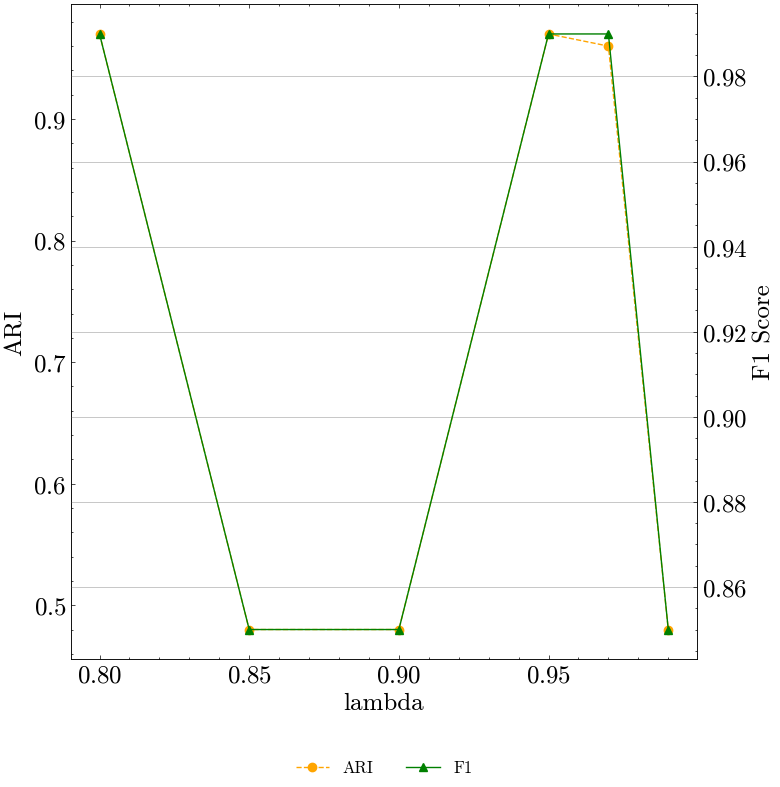

In [3]:
# Results
dict_cluster = clustering_2_communities(results_squic, squic_method, dimension)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for rho = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, save)

In [4]:
graph = visualize_graph_paysim(results_squic, squic_method, dict_cluster, account_prop, name, show_id=True)

For rho 0.99, comm mapping is : {0: '0', 1: '0', 2: '0', 3: '0', 4: '0', 5: '0', 6: '0', 7: '0', 8: '0', 9: '0', 10: '0', 11: '0', 12: '0', 13: '0', 14: '0', 15: '0', 16: '0', 17: '0', 18: '0', 19: '0', 20: '0', 21: '0', 22: '0', 23: '0', 24: '0', 25: '0', 26: '0', 27: '0', 28: '0', 29: '0', 30: '0', 31: '0', 32: '0', 33: '0', 34: '0', 35: '0', 36: '0', 37: '0', 38: '0', 39: '0', 40: '0', 41: '0', 42: '0', 43: '0', 44: '0', 45: '0', 46: '0', 47: '0', 48: '0', 49: '0', 50: '0', 51: '0', 52: '0', 53: '0', 54: '0', 55: '0', 56: '0', 57: '0', 58: '0', 59: '0', 60: '0', 61: '0', 62: '0', 63: '0', 64: '0', 65: '0', 66: '0', 67: '0', 68: '0', 69: '0', 70: '0', 71: '0', 72: '0', 73: '0', 74: '0', 75: '0', 76: '0', 77: '0', 78: '0', 79: '0', 80: '0', 81: '0', 82: '0', 83: '0', 84: '0', 85: '0', 86: '0', 87: '0', 88: '0', 89: '0', 90: '0', 91: '0', 92: '0', 93: '0', 94: '0', 95: '0', 96: '0', 97: '0', 98: '0', 99: '0', 100: '0', 101: '0', 102: '0', 103: '0', 104: '0', 105: '0', 106: '0', 107: '0

In [5]:
graph

{0.99: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color=None, point_color_by='community', point_color_by_map=[['0', '#4682B4'], ['1', '#FF9999'], ['2', '#4169E1'], ['3', '#FFD700'], ['4', '#FFCC99'], ['5', '#CCFFE5'], ['6', '#FFFF99'], ['7', '#CCFF99'], ['8', '#CCFFFF'], ['9', '#CCCCFF'], ['10', '#E9967A'], ['11', '#E5CCFF'], ['12', '#DC143C'], ['13', '#FFFFFF'], ['14', '#F0FFF0']], point_color_strategy='map', point_id_by='id', point_label_by='class', point_size_by='degree', random_seed=None, show_labels_for=['2', '3', '10', '53', '58', '61', '66', '88', '89', '107', '109', '123', '130', '145', '150', '177', '178', '211', '220', '265', '275', '292', '306', '307', '318', '320', '334', '335', '356', '370', '372', '401', '411', '419', '444', '445', '457', '468', '475', '486', '497', '501', '507', '519', '5

In [6]:
lambda_graph = {
    '100': 0.2,
    '1K': 0.8,
    '10K': 0.997,
    '100K': 0.99991
}

In [7]:
graph.get(lambda_graph.get(dimension))

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…